In [1]:

import jax 
import jax.numpy as jnp

from scoresbibm.src.utils.data_utils import load_model, query, get_summary_df

import matplotlib.pyplot as plt

In [50]:
t = jnp.linspace(0, 1, 10000)
def exp_power_scaling(t, scaling=100, max_steepness=1000, order=2):
    return jnp.exp(-t**order*scaling)*max_steepness


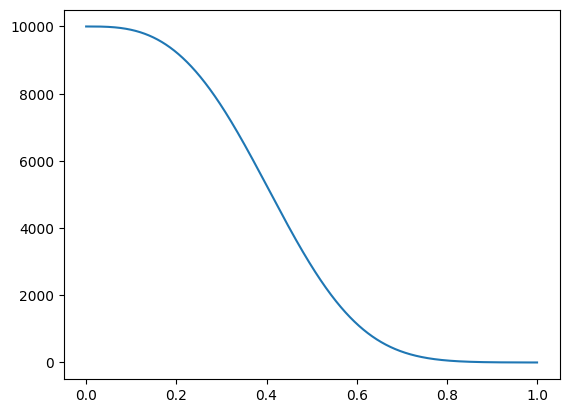

In [51]:
plt.plot(t, exp_power_scaling(t, scaling=10, max_steepness=10000, order=3))

In [52]:
# Numerical stability! (Sigmoid is numerically unstable for large values)
def log_step_fn(t,x,a,b, scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    # Box/step function approximation i.e. x \in [a,b] approx. log_sigmoid(scale * (x - a)) + log_sigmoid(scale * (b- x))
    x1 = jax.nn.log_sigmoid(scale * (x - a))
    x2 = jax.nn.log_sigmoid(scale * (b- x))
    return jnp.sum(x1 + x2, axis=1)

def log_linear_fn_approximation(t,x, a , scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    x1 = jax.nn.log_sigmoid(scale * (jnp.sum(x * a, axis=1)))
    x2 = jax.nn.log_sigmoid(-scale * (jnp.sum(x * a, axis=1)))
    return x1 + x2

def log_conditional_fn(t,x, condition_mask, x_o, scaling_fn = exp_power_scaling):
    x = x.reshape(x.shape[0],-1)
    scale = scaling_fn(t)
    x_cond = x.at[...,condition_mask].set(x_o)
    x1 = scale * (-jnp.sum(jnp.abs(x - x_cond), axis=1))
    return x1
    

def smaller_equal_constraint_fn(t,x, constrating_fn, constrain_value, scaling_fn = exp_power_scaling):
    scale = scaling_fn(t)
    constraint = jax.nn.relu(scale * (constrating_fn(x) - constrain_value)).max(axis=-1)
    constraint = jax.nn.log_sigmoid(-constraint) 
    return constraint

def log_polytope_fn_approximation(t,x, A , scaling_fn = exp_power_scaling):
    return smaller_equal_constraint_fn(t,x, lambda x: x@A.T, 1., scaling_fn=scaling_fn)

step_fn_score = jax.grad(lambda *args: log_step_fn(*args).sum(), argnums=1)
linear_fn_score = jax.grad(lambda *args: log_linear_fn_approximation(*args).sum(), argnums=1)
log_conditional_fn_score = jax.grad(lambda *args: log_conditional_fn(*args).sum(), argnums=1)
log_polytope_fn_score = jax.grad(lambda *args: log_polytope_fn_approximation(*args).sum(), argnums=1)

In [53]:
def additve_score_modifier_fn(params, t, x, node_ids, condition_mask, edge_mask, base_score_fn, mod_score_fn):
    condition_mask = condition_mask.reshape(-1,len(node_ids), 1)
    score = base_score_fn(params,t, x, node_ids=node_ids, condition_mask=jnp.zeros_like(condition_mask), edge_mask=edge_mask)
    interval_score_est = step_fn_score(t,x,a,b).reshape(-1, len(node_ids), 1) * condition_mask.reshape(-1, len(node_ids), 1)

    return score + interval_score_est

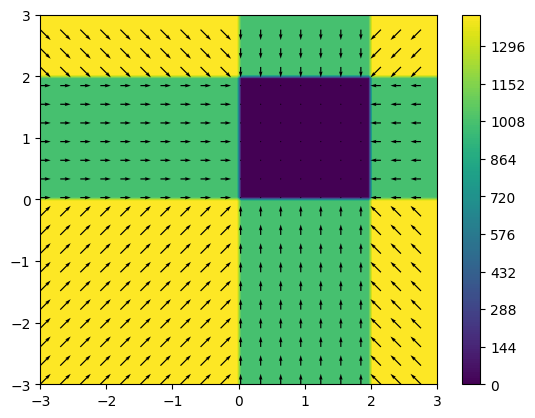

In [54]:
x = jnp.linspace(-3.,3.,100)
y = jnp.linspace(-3,3,100)
X,Y = jnp.meshgrid(x,y)
Z = jnp.stack([X,Y], axis=-1)
Z = Z.reshape(-1,2)
Z = step_fn_score(0.0001,Z, jnp.array([[0.,0.]]), jnp.array([[2.,2.]]))
Z = Z.reshape(100,100, 2)
# 2d vector field
plt.contourf(X,Y,jnp.linalg.norm(Z, axis=-1), levels=200)
plt.colorbar()
plt.quiver(X[::5,::5],Y[::5,::5],Z[::5,::5,0],Z[::5,::5,1])

In [4]:
df = get_summary_df("../results/benchmark")
df

,method,task,num_simulations,seed,model_id,metric,value,time_train,time_eval,cfg
0,score_transformer,two_moons,1000,0,0,c2st,"[0.7907999753952026, 0.8011000156402588, 0.762...",405.382012,14.105814,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
1,score_transformer,two_moons,1000,0,1,c2st,"[0.6054499745368958, 0.6200000047683716, 0.600...",243.004187,6.925381,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
2,nspe,two_moons,1000,0,2,c2st,"[0.5515499711036682, 0.5672500133514404, 0.559...",28.093741,2.267969,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
3,nspe,two_moons,1000,0,3,c2st,"[0.5515000224113464, 0.5699999928474426, 0.559...",27.465629,2.258880,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
4,score_transformer,two_moons,1000,0,4,c2st,"[0.6014000177383423, 0.6244999766349792, 0.598...",335.166889,10.352422,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
5,score_transformer,two_moons,1000,0,5,c2st,"[0.5852000117301941, 0.6082500219345093, 0.594...",336.818093,10.470732,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
6,score_transformer,two_moons,1000,0,6,c2st,"[0.5613499879837036, 0.6060500144958496, 0.593...",224.148223,11.101278,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
7,score_transformer,two_moons,10000,0,7,c2st,"[0.5539000034332275, 0.5623000264167786, 0.557...",552.478095,12.229207,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
8,score_transformer,two_moons,10000,0,8,c2st,"[0.5506500005722046, 0.5593500137329102, 0.566...",725.672236,13.144215,"{'name': 'benchmark', 'seed': 0, 'save_model':..."
9,score_transformer_joint,two_moons,10000,0,9,c2st,"[0.9100499749183655, 0.9362499713897705, 0.871...",552.936099,12.283738,"{'name': 'benchmark', 'seed': 0, 'save_model':..."


In [3]:
model = load_model("../results/benchmark/",23)

In [4]:
from probjax.utils.sdeint import register_method

In [5]:
x_o = jnp.array([0.,0.])
condition_mask = jnp.array([False, False, True, True])

In [14]:
#with jax.disable_jit():
samples = model.sample(1000, x_o=x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(0),sampling_method="generalized_guidance",num_steps=1000, score_manipulator="interval", score_manipulator_kwargs={"a":0.1, "b":1.5})

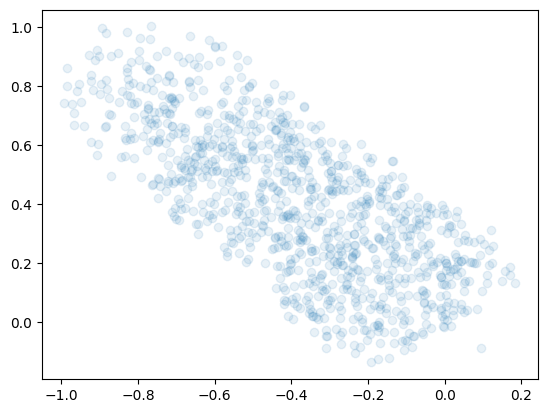

In [15]:
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)

In [5]:
register_repaint_step_fn(model, condition_mask, x_o)

NameError: name 'register_repaint_step_fn' is not defined